In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import glob
import sys
import pdb
sys.path.insert(1, '/Users/joe/repos/climate_utils')
import climate_toolbox as ctb
%matplotlib inline
from datetime import datetime
from scipy.optimize import curve_fit

lat_avg  = lambda data: data.weighted(np.cos(np.deg2rad(data.latitude))).mean('latitude')
lon_avg  = lambda data: data.mean('longitude')
horz_avg = lambda data: lon_avg(lat_avg(data))

In [2]:
# -------- get all simulations in the MIP ----------
loc  = '/Users/joe/repos/climate_analysis/OCO/TM5-GC-inversion-comps'
mip  = 'OCO2_v11MIP_gridded_fluxes_all_20260127'
pdir = 'processed_data'
all_runs = glob.glob(f'{loc}/{mip}/*.nc4')

# -------- get all models and observational sets ----------
all_models = sorted(np.unique([run.split('/')[-1].split('_')[0] for run in all_runs]))
all_obs    = sorted(np.unique([run.split('/')[-1].split('_')[-1].strip('.nc4') for run in all_runs]))
gc_models  = ['Ames', 'CMS-Flux', 'GCAS', 'JHU', 'WOMBAT-GC']
N_gc       = len(gc_models)
tm5_models = ['CT', 'CT-MP', 'TM5-4DVAR', 'WOMBAT-TM5']
N_tm5      = len(gc_models)

# -------- build model dictionary ----------
models = {}
for model in all_models:
    models[model] = {}
    for obs in all_obs:
        models[model][obs] = glob.glob(f'{loc}/{mip}/*{model}*_{obs}*.nc4')[0]
N = len(all_models)

# -------- get all flux components ----------
all_fluxes  = sorted(list(xr.open_dataset(models['WOMBAT-GC']['LNLGIS']).data_vars))[1:]
flux_colors = ['indianred', 'yellowgreen', 'cornflowerblue']

print(all_models)
print(all_obs)
print(all_fluxes)

['Ames', 'CAMS', 'CMS-Flux', 'CMS-MFlux', 'CT', 'CT-MP', 'GCAS', 'GONGGA', 'JHU', 'NISMON-CO2', 'NTFVAR', 'PCTM', 'TM5-4DVAR', 'WOMBAT-GC', 'WOMBAT-TM5']
['IS', 'LNLG', 'LNLGIS', 'LNLGOGIS', 'Prior']
['fossil_flux', 'land_flux', 'ocean_flux']


In [3]:
xr.open_dataset(models['WOMBAT-GC']['IS'])

<xarray.Dataset>
Dimensions:              (longitude: 360, latitude: 180, time: 115,
                          num_calendar_components: 6)
Coordinates:
  * longitude            (longitude) float64 -179.5 -178.5 ... 178.5 179.5
  * latitude             (latitude) float64 -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * time                 (time) datetime64[ns] 2014-09-16T00:00:00.500000 ......
Dimensions without coordinates: num_calendar_components
Data variables:
    land_flux            (time, latitude, longitude) float32 ...
    ocean_flux           (time, latitude, longitude) float32 ...
    fossil_flux          (time, latitude, longitude) float32 ...
    calendar_components  (time, num_calendar_components) float64 ...
Attributes:
    history:  Created on Thu Aug 14 2025 19:42:34 UTC\nby script 'Time-stamp:...

In [5]:
overwrite=False

ens_gc       = {}
ens_tm5      = {}
ens_mean     = {}
ens_gc_mean  = {}
ens_tm5_mean = {}
ens_std      = {}
ens_gc_std   = {}
ens_tm5_std  = {}

# -------- get ensemble means
for obs in all_obs:

    # ---- full ensemble
    try:
        if(overwrite): raise FileNotFoundError
        ens_mean[obs] = xr.open_dataset(f'{loc}/{pdir}/ens_{obs}.nc4')
        ens_std[obs]  = xr.open_dataset(f'{loc}/{pdir}/ens_std_{obs}.nc4')
        print(f'read ensemble mean for {obs} from file')
    except FileNotFoundError:
        print(f'computing ensemble mean for {obs}')
        ens[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in all_models], 
                        dim=xr.DataArray(all_models, dims="model", name="model"))
        
        ens_std[obs]  = ens[obs].std('model')
        ens_std[obs].to_netcdf(f'{loc}/{pdir}/ens_std_{obs}.nc4')
        ens_mean[obs] = ens[obs].mean('model')
        ens_mean[obs].to_netcdf(f'{loc}/{pdir}/ens_{obs}.nc4')

    # ---- GC ensemble
    ens_gc[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in gc_models], 
                             dim=xr.DataArray(gc_models, dims="model", name="model"))
    try:
        if(overwrite): raise FileNotFoundError
        ens_gc_mean[obs] = xr.open_dataset(f'{loc}/{pdir}/ens_gc_{obs}.nc4')
        ens_gc_std[obs]  = xr.open_dataset(f'{loc}/{pdir}/ens_gc_std_{obs}.nc4')
        print(f'read ensemble mean for {obs} from file')
    except FileNotFoundError:
        print(f'computing GC ensemble mean for {obs}')
        ens_gc_std[obs]  = ens_gc[obs].std('model')
        ens_gc_std[obs].to_netcdf(f'{loc}/{pdir}/ens_gc_std_{obs}.nc4')
        ens_gc_mean[obs] = ens_gc[obs].mean('model')
        ens_gc_mean[obs].to_netcdf(f'{loc}/{pdir}/ens_gc_{obs}.nc4')

    # ---- TM5 ensemble
    ens_tm5[obs] = xr.concat([xr.open_dataset(models[model][obs]) for model in tm5_models], 
                              dim=xr.DataArray(tm5_models, dims="model", name="model"))
    try:
        if(overwrite): raise FileNotFoundError
        ens_tm5_mean[obs] = xr.open_dataset(f'{loc}/{pdir}/ens_tm5_{obs}.nc4')
        ens_tm5_std[obs]  = xr.open_dataset(f'{loc}/{pdir}/ens_tm5_std_{obs}.nc4')
        print(f'read ensemble mean for {obs} from file')
    except FileNotFoundError:
        print(f'computing TM5 ensemble mean for {obs}')
        ens_tm5_std[obs]  = ens_tm5[obs].std('model')
        ens_tm5_std[obs].to_netcdf(f'{loc}/{pdir}/ens_tm5_std_{obs}.nc4')
        ens_tm5_mean[obs] = ens_tm5[obs].mean('model')
        ens_tm5_mean[obs].to_netcdf(f'{loc}/{pdir}/ens_tm5_{obs}.nc4')

print('done')

read ensemble mean for IS from file
read ensemble mean for IS from file
read ensemble mean for IS from file
read ensemble mean for LNLG from file
read ensemble mean for LNLG from file
read ensemble mean for LNLG from file
read ensemble mean for LNLGIS from file
read ensemble mean for LNLGIS from file
read ensemble mean for LNLGIS from file
read ensemble mean for LNLGOGIS from file
read ensemble mean for LNLGOGIS from file
read ensemble mean for LNLGOGIS from file
read ensemble mean for Prior from file
read ensemble mean for Prior from file
read ensemble mean for Prior from file
done


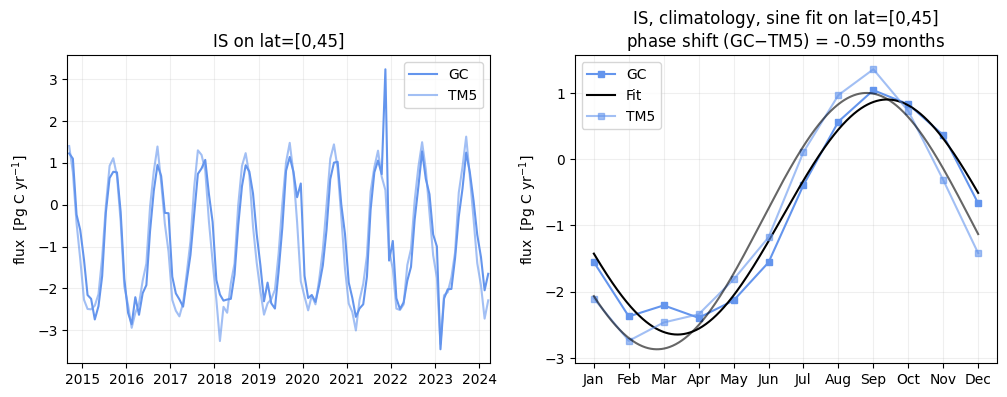

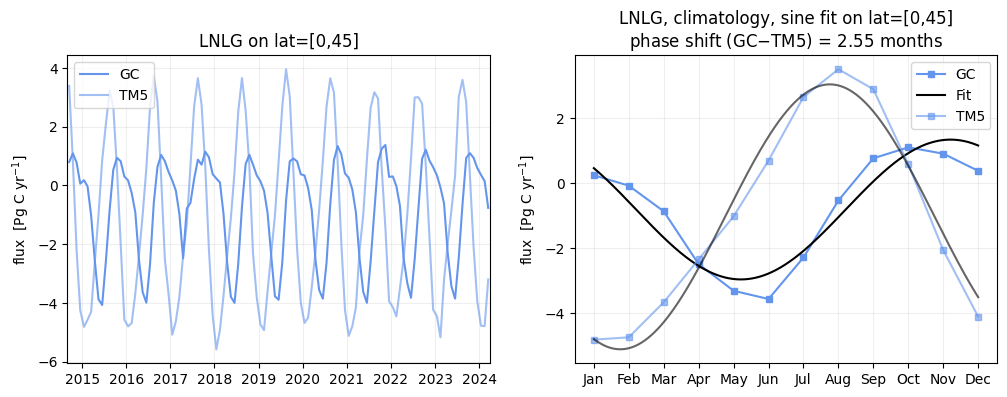

In [6]:
# look at wombat GC-TM5 differences in zonal bands

lat0, lat1 = 0, 45

for obs in ['IS', 'LNLG']:
    gc  = xr.open_dataset(models['WOMBAT-GC'][obs]) * 100
    tm5 = xr.open_dataset(models['WOMBAT-TM5'][obs]) * 100
    gc  = horz_avg(gc.sel(latitude=slice(lat0, lat1)))
    tm5 = horz_avg(tm5.sel(latitude=slice(lat0, lat1)))
    gc_climo  = ctb.compute_climatology(gc)
    tm5_climo = ctb.compute_climatology(tm5)

    months      = gc_climo.month.values
    months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gc_climo.month.values]
    months_fine = np.linspace(min(months), max(months), 1000)

    if(1):
        fig = plt.figure(figsize=(12, 4))
        ax   = fig.add_subplot(121)
        axs  = fig.add_subplot(122)

        # ------ plot monthly time series
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):
                ax.plot(gc.time, gc[flux], '-', color=flux_colors[i], label='GC')
                ax.plot(tm5.time, tm5[flux], '-', color=flux_colors[i], label='TM5', alpha=0.6)
        ax.legend()
        ax.set_ylabel('flux  [Pg C yr$^{-1}$]')
        ax.set_title(f'{obs} on lat=[{lat0},{lat1}]')
        ax.grid(alpha=0.2)
        ax.set_xlim([datetime(2014,9,1), datetime(2024,4,1)])
        
        # VV freq is constrained to 1/year
        sine_model = lambda x, A, phi, C: A * np.sin((2*np.pi/12) * x + phi) + C
        initial_guess = [1, 0, 0]
        
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):

                gc_params, gc_covariance = curve_fit(sine_model, gc_climo.month, np.array(gc_climo[flux]), p0=initial_guess)
                tm5_params, tm5_covariance = curve_fit(sine_model, tm5_climo.month, np.array(tm5_climo[flux]), p0=initial_guess)
                phase_shift = (gc_params[-2]-tm5_params[-2]) / (2*np.pi/12)
                
                axs.plot(months, gc_climo[flux], '-', color=flux_colors[i], label='GC', ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *gc_params), '-k', label="Fit")
                axs.plot(months, tm5_climo[flux], '-', color=flux_colors[i], label='TM5', alpha=0.6, ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *tm5_params), '-k', alpha=0.6)
                
        axs.legend()
        axs.set_ylabel('flux  [Pg C yr$^{-1}$]')
        axs.set_title(f'{obs}, climatology, sine fit on lat=[{lat0},{lat1}]\nphase shift (GC$-$TM5) = {phase_shift:.2f} months')
        axs.grid(alpha=0.2)
        #axs.set_xlim([1, 12])
        axs.xaxis.set_ticks(months)
        axs.xaxis.set_ticklabels(months_abbr)

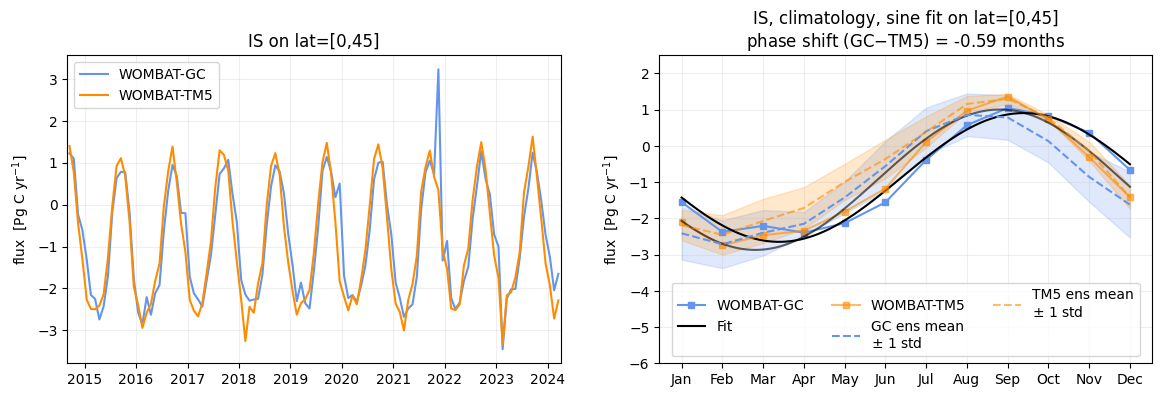

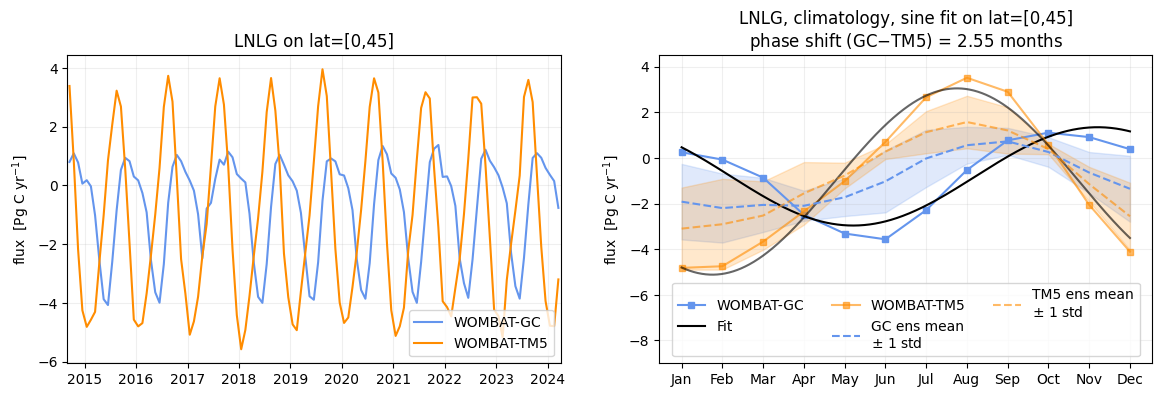

In [7]:
# look at wombat GC-TM5 differences in zonal bands

lat0, lat1 = 0, 45
gc_color  = 'cornflowerblue'
tm5_color = 'darkorange'

for obs in ['IS', 'LNLG']:
    gc  = xr.open_dataset(models['WOMBAT-GC'][obs]) * 100
    tm5 = xr.open_dataset(models['WOMBAT-TM5'][obs]) * 100
    gc  = horz_avg(gc.sel(latitude=slice(lat0, lat1)))
    tm5 = horz_avg(tm5.sel(latitude=slice(lat0, lat1)))
    gc_climo  = ctb.compute_climatology(gc)
    tm5_climo = ctb.compute_climatology(tm5)

    # get ensemble means and err
    gcem  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0, lat1))) * 100
    tm5em = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0, lat1))) * 100
    gcem_climo  = ctb.compute_climatology(gcem)
    tm5em_climo = ctb.compute_climatology(tm5em)
    gcem_climo = gcem_climo.mean('model')
    tm5em_climo = tm5em_climo.mean('model')

    gcerr  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0, lat1))) * 100
    tm5err = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0, lat1))) * 100
    gcerr_climo  = ctb.compute_climatology(gcerr)
    tm5err_climo = ctb.compute_climatology(tm5err)
    gcerr_climo = gcerr_climo.std('model')
    tm5err_climo = tm5err_climo.std('model')

    months      = gc_climo.month.values
    months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gc_climo.month.values]
    months_fine = np.linspace(min(months), max(months), 1000)

    if(1):
        fig = plt.figure(figsize=(14, 4))
        ax   = fig.add_subplot(121)
        #axc  = fig.add_subplot(122)
        axs  = fig.add_subplot(122)

        # ------ plot monthly time series
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):
                ax.plot(gc.time, gc[flux], '-', color=gc_color, label='WOMBAT-GC')
                ax.plot(tm5.time, tm5[flux], '-', color=tm5_color, label='WOMBAT-TM5')
        ax.legend()
        ax.set_ylabel('flux  [Pg C yr$^{-1}$]')
        ax.set_title(f'{obs} on lat=[{lat0},{lat1}]')
        ax.grid(alpha=0.2)
        ax.set_xlim([datetime(2014,9,1), datetime(2024,4,1)])
        
        # VV freq is constrained to 1/year
        sine_model = lambda x, A, phi, C: A * np.sin((2*np.pi/12) * x + phi) + C
        initial_guess = [1, 0, 0]
        
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):

                gc_params, gc_covariance = curve_fit(sine_model, gc_climo.month, np.array(gc_climo[flux]), p0=initial_guess)
                tm5_params, tm5_covariance = curve_fit(sine_model, tm5_climo.month, np.array(tm5_climo[flux]), p0=initial_guess)
                phase_shift = (gc_params[-2]-tm5_params[-2]) / (2*np.pi/12)
                
                axs.plot(months, gc_climo[flux], '-', color=gc_color, label='WOMBAT-GC', ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *gc_params), '-k', label="Fit")
                axs.plot(months, tm5_climo[flux], '-', color=tm5_color, label='WOMBAT-TM5', alpha=0.6, ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *tm5_params), '-k', alpha=0.6)

                # also plot ensemble means with shaded error
                axs.plot(months, gcem_climo[flux], '--', color=gc_color, label='GC ens mean\n$\pm$ 1 std')
                axs.fill_between(months, gcem_climo[flux]-gcerr_climo[flux], gcem_climo[flux]+gcerr_climo[flux], 
                                 color=gc_color, alpha=0.2)
                axs.plot(months, tm5em_climo[flux], '--', color=tm5_color, label='TM5 ens mean\n$\pm$ 1 std', alpha=0.6)
                axs.fill_between(months, tm5em_climo[flux]-tm5err_climo[flux], tm5em_climo[flux]+tm5err_climo[flux], 
                                 color=tm5_color, alpha=0.2)

                if(obs == 'IS'):
                    axs.set_ylim([-6, 2.5])
                else:
                    axs.set_ylim([-9, 4.5])
                
        axs.legend(ncol=3, loc='lower center')
        axs.set_ylabel('flux  [Pg C yr$^{-1}$]')
        axs.set_title(f'{obs}, climatology, sine fit on lat=[{lat0},{lat1}]\nphase shift (GC$-$TM5) = {phase_shift:.2f} months')
        axs.grid(alpha=0.2)
        #axs.set_xlim([1, 12])
        axs.xaxis.set_ticks(months)
        axs.xaxis.set_ticklabels(months_abbr)

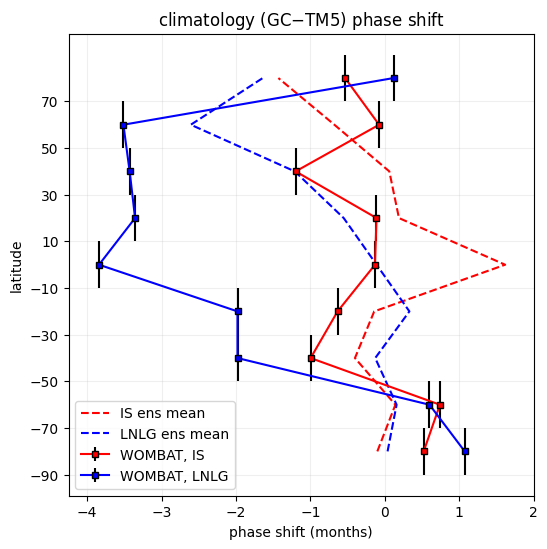

In [8]:
# look at wombat GC-TM5 differences in zonal bands

dlat = 20
lat0 = np.arange(-90, 90-dlat+1, dlat)
lat1 = np.arange(-90+dlat, 90+1, dlat)
latc = np.arange(-90+dlat/2, 90-dlat/2 + 1, dlat)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
colors = ['r', 'b']

for k,obs in enumerate(['IS', 'LNLG']):

    for j,flux in enumerate(all_fluxes):
        if('ocean' not in flux): continue
            
        phase_shift = np.zeros(len(lat0))
        phase_shift_em = np.zeros(len(lat0))
        phase_shift_err1 = np.zeros(len(lat0))
        phase_shift_err2 = np.zeros(len(lat0))
        
        for j in range(len(lat0)):
            gc  = xr.open_dataset(models['WOMBAT-GC'][obs]) * 100
            tm5 = xr.open_dataset(models['WOMBAT-TM5'][obs]) * 100
            gc  = horz_avg(gc.sel(latitude=slice(lat0[j], lat1[j])))
            tm5 = horz_avg(tm5.sel(latitude=slice(lat0[j], lat1[j])))
            gc_climo  = ctb.compute_climatology(gc)
            tm5_climo = ctb.compute_climatology(tm5)

            # get ensemble means and std
            gcem  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0[j], lat1[j]))) * 100
            tm5em = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0[j], lat1[j]))) * 100
            gcem_climo  = ctb.compute_climatology(gcem)
            tm5em_climo = ctb.compute_climatology(tm5em)
            gcem_climo = gcem_climo.mean('model')
            tm5em_climo = tm5em_climo.mean('model')
        
            months      = gc_climo.month.values
            months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gc_climo.month.values]
            months_fine = np.linspace(min(months), max(months), 1000)
        
            sine_model = lambda x, A, phi, C: A * np.sin((2*np.pi/12) * x + phi) + C
            initial_guess = [10, 0, 0]
            
            gc_params, gc_covariance = curve_fit(sine_model, gc_climo.month, np.array(gc_climo[flux]), p0=initial_guess)
            tm5_params, tm5_covariance = curve_fit(sine_model, tm5_climo.month, np.array(tm5_climo[flux]), p0=initial_guess)
            phase_shift[j] = (gc_params[-2]-tm5_params[-2]) / (2*np.pi/12)

            # fit also for the ensemble means
            gcem_params, gcem_covariance = curve_fit(sine_model, gcem_climo.month, np.array(gcem_climo[flux]), p0=initial_guess)
            tm5em_params, tm5em_covariance = curve_fit(sine_model, tm5em_climo.month, np.array(tm5em_climo[flux]), p0=initial_guess)
            phase_shift_em[j] = (gcem_params[-2]-tm5em_params[-2]) / (2*np.pi/12)
            # and the bounds of the error
            if(0):
                gcerr1_params, gcerr1_covariance = curve_fit(sine_model, gcem_climo.month, np.array(gcem_climo[flux] - gcerr_climo[flux]), p0=initial_guess)
                tm5err1_params, tm5err1_covariance = curve_fit(sine_model, tm5em_climo.month, np.array(tm5em_climo[flux] - tm5err_climo[flux]), p0=initial_guess)
                phase_shift_err1[j] = (gcerr1_params[-2]-tm5err1_params[-2]) / (2*np.pi/12)
                gcerr2_params, gcerr2_covariance = curve_fit(sine_model, gcem_climo.month, np.array(gcem_climo[flux] + gcerr_climo[flux]), p0=initial_guess)
                tm5err2_params, tm5err2_covariance = curve_fit(sine_model, tm5em_climo.month, np.array(tm5em_climo[flux] + tm5err_climo[flux]), p0=initial_guess)
                phase_shift_err2[j] = (gcerr2_params[-2]-tm5err2_params[-2]) / (2*np.pi/12)
            
        ax.errorbar(phase_shift, latc, yerr=dlat/2, linestyle='-', marker='s', ms=5, markeredgecolor='k', ecolor='k', color=colors[k], label=f'WOMBAT, {obs}')
        ax.plot(phase_shift_em, latc, linestyle='--', color=colors[k], label=f'{obs} ens mean')
        if(0):
            ax.fill_betweenx(latc, phase_shift_err1, phase_shift_err2, latc, color=colors[k], alpha=0.2)

ax.legend(loc='lower left')
ax.set_xlabel('phase shift (months)')
ax.set_ylabel('latitude')
ax.set_title(f'climatology (GC$-$TM5) phase shift')
ax.grid(alpha=0.2)
ax.set_xlim([-4.25, 2])
ax.yaxis.set_ticks(lat0)

[-90 -85 -80 -75 -70 -65 -60 -55 -50 -45 -40 -35 -30 -25 -20 -15 -10  -5
   0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80]
[-85 -80 -75 -70 -65 -60 -55 -50 -45 -40 -35 -30 -25 -20 -15 -10  -5   0
   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85]
[-80 -75 -70 -65 -60 -55 -50 -45 -40 -35 -30 -25 -20 -15 -10  -5   0   5
  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90]


(-50.0, 50.0)

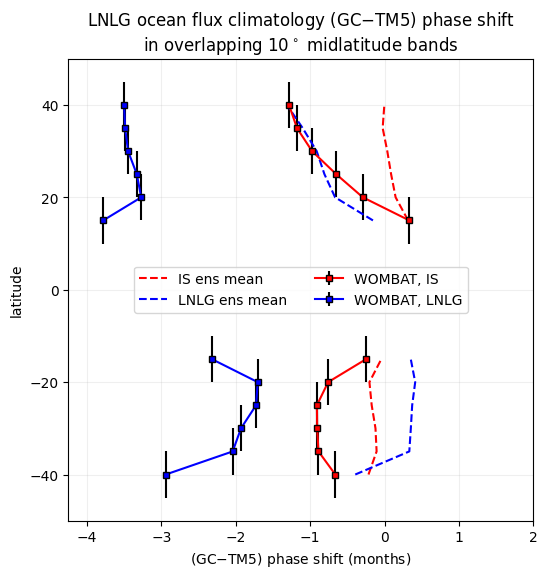

In [9]:
# look at wombat GC-TM5 differences in zonal bands

dlat = 5
lat0_G = np.arange(-90, 90-2*dlat+1, dlat)
lat1_G = np.arange(-90+2*dlat, 90+1, dlat)
latc_G = np.arange(-90+dlat, 90-dlat + 1, dlat)

print(lat0_G)
print(latc_G)
print(lat1_G)

lat0_S = lat0_G[np.logical_and(latc_G < -10, latc_G > -45)]
lat1_S = lat1_G[np.logical_and(latc_G < -10, latc_G > -45)]
latc_S = latc_G[np.logical_and(latc_G < -10, latc_G > -45)]

lat0_N = lat0_G[np.logical_and(latc_G > 10, latc_G < 45)]
lat1_N = lat1_G[np.logical_and(latc_G > 10, latc_G < 45)]
latc_N = latc_G[np.logical_and(latc_G > 10, latc_G < 45)]

lat0_all = [lat0_S, lat0_N]
lat1_all = [lat1_S, lat1_N]
latc_all = [latc_S, latc_N]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
colors = ['r', 'b']

for k,obs in enumerate(['IS', 'LNLG']):

    for j,flux in enumerate(all_fluxes):
        if('ocean' not in flux): continue

        for ll in range(2):
            lat0, lat1, latc = lat0_all[ll], lat1_all[ll], latc_all[ll]

            phase_shift = np.zeros(len(lat0))
            phase_shift_em = np.zeros(len(lat0))
            phase_shift_err1 = np.zeros(len(lat0))
            phase_shift_err2 = np.zeros(len(lat0))
        
            for j in range(len(lat0)):
                
                gc  = xr.open_dataset(models['WOMBAT-GC'][obs]) * 100
                tm5 = xr.open_dataset(models['WOMBAT-TM5'][obs]) * 100
                gc  = horz_avg(gc.sel(latitude=slice(lat0[j], lat1[j])))
                tm5 = horz_avg(tm5.sel(latitude=slice(lat0[j], lat1[j])))
                gc_climo  = ctb.compute_climatology(gc)
                tm5_climo = ctb.compute_climatology(tm5)
    
                # get ensemble means and std
                gcem  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0[j], lat1[j]))) * 100
                tm5em = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0[j], lat1[j]))) * 100
                gcem_climo  = ctb.compute_climatology(gcem)
                tm5em_climo = ctb.compute_climatology(tm5em)
                gcem_climo  = gcem_climo.mean('model')
                tm5em_climo = tm5em_climo.mean('model')
            
                months      = gc_climo.month.values
                months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gc_climo.month.values]
                months_fine = np.linspace(min(months), max(months), 1000)
            
                sine_model = lambda x, A, phi, C: A * np.sin((2*np.pi/12) * x + phi) + C
                initial_guess = [10, 0, 0]
                
                gc_params, gc_covariance = curve_fit(sine_model, gc_climo.month, np.array(gc_climo[flux]), p0=initial_guess)
                tm5_params, tm5_covariance = curve_fit(sine_model, tm5_climo.month, np.array(tm5_climo[flux]), p0=initial_guess)
                phase_shift[j] = (gc_params[-2]-tm5_params[-2]) / (2*np.pi/12)
    
                # fit also for the ensemble means
                gcem_params, gcem_covariance = curve_fit(sine_model, gcem_climo.month, np.array(gcem_climo[flux]), p0=initial_guess)
                tm5em_params, tm5em_covariance = curve_fit(sine_model, tm5em_climo.month, np.array(tm5em_climo[flux]), p0=initial_guess)
                phase_shift_em[j] = (gcem_params[-2]-tm5em_params[-2]) / (2*np.pi/12)
                # and the bounds of the error
                if(0):
                    gcerr1_params, gcerr1_covariance = curve_fit(sine_model, gcem_climo.month, np.array(gcem_climo[flux] - gcerr_climo[flux]), p0=initial_guess)
                    tm5err1_params, tm5err1_covariance = curve_fit(sine_model, tm5em_climo.month, np.array(tm5em_climo[flux] - tm5err_climo[flux]), p0=initial_guess)
                    phase_shift_err1[j] = (gcerr1_params[-2]-tm5err1_params[-2]) / (2*np.pi/12)
                    gcerr2_params, gcerr2_covariance = curve_fit(sine_model, gcem_climo.month, np.array(gcem_climo[flux] + gcerr_climo[flux]), p0=initial_guess)
                    tm5err2_params, tm5err2_covariance = curve_fit(sine_model, tm5em_climo.month, np.array(tm5em_climo[flux] + tm5err_climo[flux]), p0=initial_guess)
                    phase_shift_err2[j] = (gcerr2_params[-2]-tm5err2_params[-2]) / (2*np.pi/12)

            if(ll == 0): label_e, label_p = f'WOMBAT, {obs}', f'{obs} ens mean'
            else:        label_e, label_p = None, None
            ax.errorbar(phase_shift, latc, yerr=dlat, linestyle='-', marker='s', ms=5, markeredgecolor='k', ecolor='k', color=colors[k], label=label_e)
            ax.plot(phase_shift_em, latc, linestyle='--', color=colors[k], label=label_p)
            if(0):
                ax.fill_betweenx(latc, phase_shift_err1, phase_shift_err2, latc, color=colors[k], alpha=0.2)

ax.legend(loc='center', ncol=2)
ax.set_xlabel('(GC$-$TM5) phase shift (months)')
ax.set_ylabel('latitude')
ax.set_title(f'LNLG ocean flux climatology (GC$-$TM5) phase shift\nin overlapping {dlat*2}$^\circ$ midlatitude bands')
ax.grid(alpha=0.2)
ax.set_xlim([-4.25, 2])
#ax.yaxis.set_ticks(np.unique(np.concatenate([lat0_G, lat1_G])))
ax.set_ylim([-50, 50])

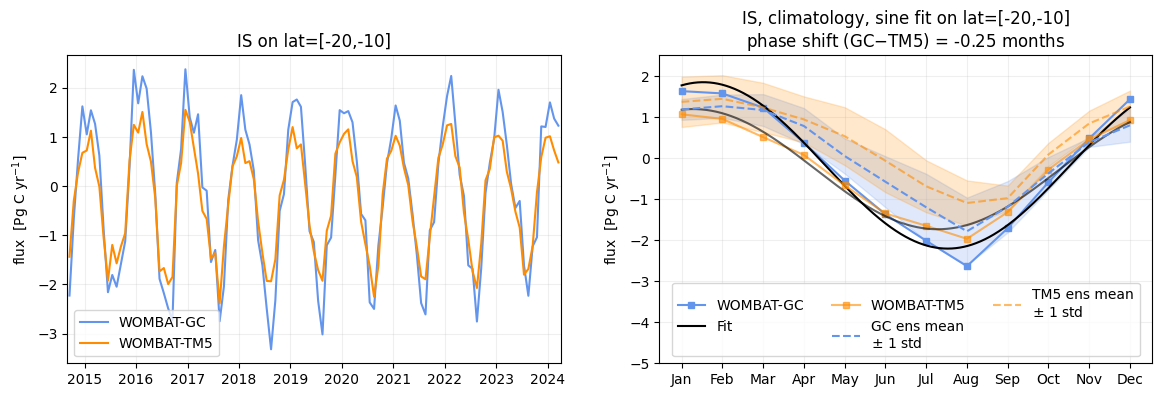

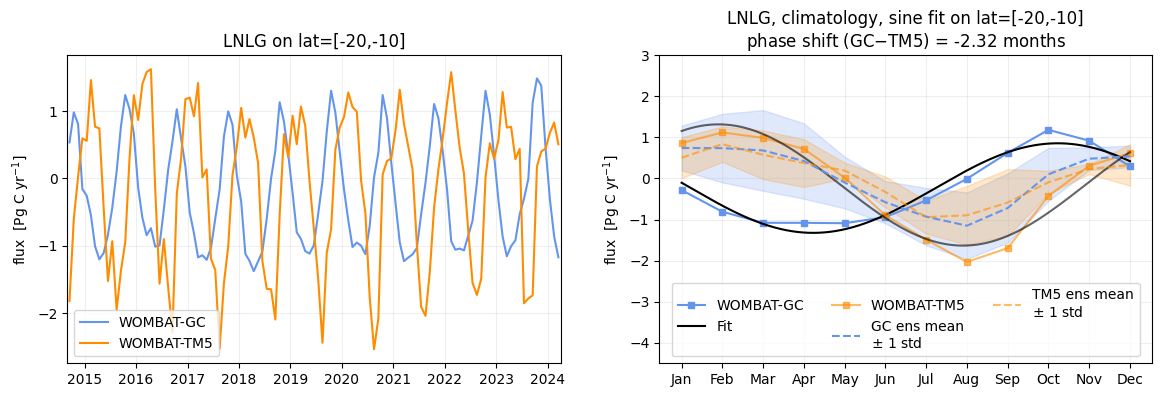

In [10]:
# look at wombat GC-TM5 differences in zonal bands

lat0, lat1 = -20, -10
gc_color  = 'cornflowerblue'
tm5_color = 'darkorange'

for obs in ['IS', 'LNLG']:
    gc  = xr.open_dataset(models['WOMBAT-GC'][obs]) * 100
    tm5 = xr.open_dataset(models['WOMBAT-TM5'][obs]) * 100
    gc  = horz_avg(gc.sel(latitude=slice(lat0, lat1)))
    tm5 = horz_avg(tm5.sel(latitude=slice(lat0, lat1)))
    gc_climo  = ctb.compute_climatology(gc)
    tm5_climo = ctb.compute_climatology(tm5)

    # get ensemble means and err
    gcem  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0, lat1))) * 100
    tm5em = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0, lat1))) * 100
    gcem_climo  = ctb.compute_climatology(gcem)
    tm5em_climo = ctb.compute_climatology(tm5em)
    gcem_climo = gcem_climo.mean('model')
    tm5em_climo = tm5em_climo.mean('model')

    gcerr  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0, lat1))) * 100
    tm5err = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0, lat1))) * 100
    gcerr_climo  = ctb.compute_climatology(gcerr) 
    tm5err_climo = ctb.compute_climatology(tm5err)
    gcerr_climo = gcerr_climo.std('model')
    tm5err_climo = tm5err_climo.std('model')

    months      = gc_climo.month.values
    months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gc_climo.month.values]
    months_fine = np.linspace(min(months), max(months), 1000)

    if(1):
        fig = plt.figure(figsize=(14, 4))
        ax   = fig.add_subplot(121)
        #axc  = fig.add_subplot(122)
        axs  = fig.add_subplot(122)

        # ------ plot monthly time series
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):
                ax.plot(gc.time, gc[flux], '-', color=gc_color, label='WOMBAT-GC')
                ax.plot(tm5.time, tm5[flux], '-', color=tm5_color, label='WOMBAT-TM5')
        ax.legend()
        ax.set_ylabel('flux  [Pg C yr$^{-1}$]')
        ax.set_title(f'{obs} on lat=[{lat0},{lat1}]')
        ax.grid(alpha=0.2)
        ax.set_xlim([datetime(2014,9,1), datetime(2024,4,1)])
        
        # VV freq is constrained to 1/year
        sine_model = lambda x, A, phi, C: A * np.sin((2*np.pi/12) * x + phi) + C
        initial_guess = [10, 0, 0]
        
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):

                gc_params, gc_covariance = curve_fit(sine_model, gc_climo.month, np.array(gc_climo[flux]), p0=initial_guess)
                tm5_params, tm5_covariance = curve_fit(sine_model, tm5_climo.month, np.array(tm5_climo[flux]), p0=initial_guess)
                phase_shift = (gc_params[-2]-tm5_params[-2]) / (2*np.pi/12)
                
                axs.plot(months, gc_climo[flux], '-', color=gc_color, label='WOMBAT-GC', ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *gc_params), '-k', label="Fit")
                axs.plot(months, tm5_climo[flux], '-', color=tm5_color, label='WOMBAT-TM5', alpha=0.6, ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *tm5_params), '-k', alpha=0.6)

                # also plot ensemble means with shaded error
                axs.plot(months, gcem_climo[flux], '--', color=gc_color, label='GC ens mean\n$\pm$ 1 std')
                axs.fill_between(months, gcem_climo[flux]-gcerr_climo[flux], gcem_climo[flux]+gcerr_climo[flux], 
                                 color=gc_color, alpha=0.2)
                axs.plot(months, tm5em_climo[flux], '--', color=tm5_color, label='TM5 ens mean\n$\pm$ 1 std', alpha=0.6)
                axs.fill_between(months, tm5em_climo[flux]-tm5err_climo[flux], tm5em_climo[flux]+tm5err_climo[flux], 
                                 color=tm5_color, alpha=0.2)

                if(obs == 'IS'):
                    axs.set_ylim([-5, 2.5])
                else:
                    axs.set_ylim([-4.5, 3])
                
        axs.legend(ncol=3, loc='lower center')
        axs.set_ylabel('flux  [Pg C yr$^{-1}$]')
        axs.set_title(f'{obs}, climatology, sine fit on lat=[{lat0},{lat1}]\nphase shift (GC$-$TM5) = {phase_shift:.2f} months')
        axs.grid(alpha=0.2)
        #axs.set_xlim([1, 12])
        axs.xaxis.set_ticks(months)
        axs.xaxis.set_ticklabels(months_abbr)

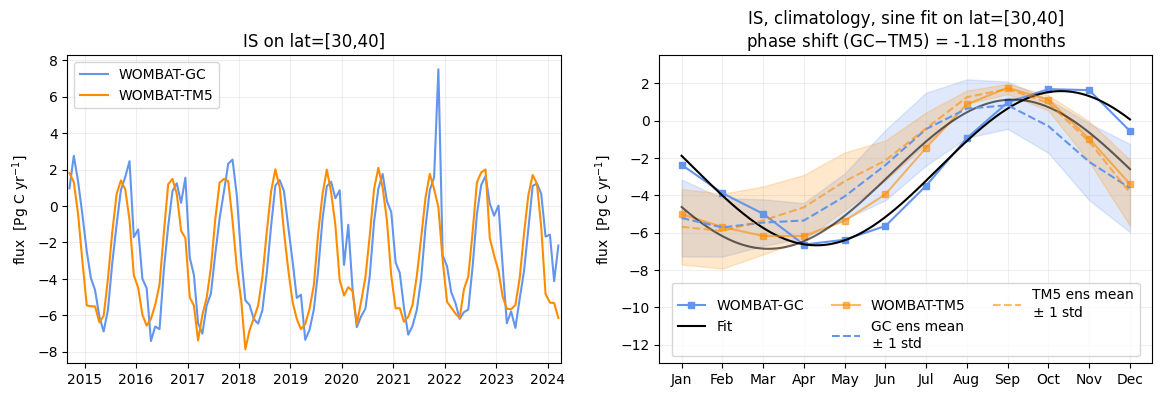

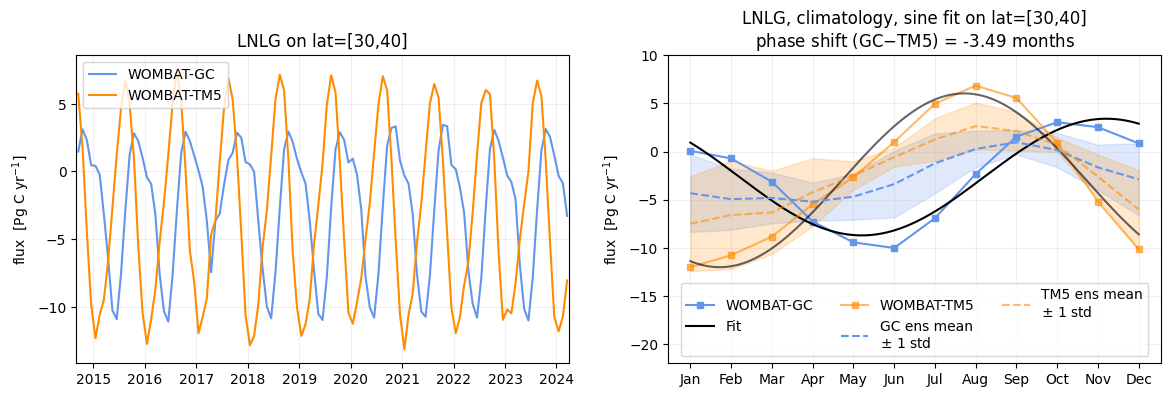

In [11]:
# look at wombat GC-TM5 differences in zonal bands

lat0, lat1 = 30, 40
gc_color  = 'cornflowerblue'
tm5_color = 'darkorange'

for obs in ['IS', 'LNLG']:
    gc  = xr.open_dataset(models['WOMBAT-GC'][obs]) * 100
    tm5 = xr.open_dataset(models['WOMBAT-TM5'][obs]) * 100
    gc  = horz_avg(gc.sel(latitude=slice(lat0, lat1)))
    tm5 = horz_avg(tm5.sel(latitude=slice(lat0, lat1)))
    gc_climo  = ctb.compute_climatology(gc)
    tm5_climo = ctb.compute_climatology(tm5)

    # get ensemble means and err
    gcem  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0, lat1))) * 100
    tm5em = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0, lat1))) * 100
    gcem_climo  = ctb.compute_climatology(gcem)
    tm5em_climo = ctb.compute_climatology(tm5em)
    gcem_climo = gcem_climo.mean('model')
    tm5em_climo = tm5em_climo.mean('model')

    gcerr  = horz_avg(ens_gc[obs].sel(latitude=slice(lat0, lat1))) * 100
    tm5err = horz_avg(ens_tm5[obs].sel(latitude=slice(lat0, lat1))) * 100
    gcerr_climo  = ctb.compute_climatology(gcerr)
    tm5err_climo = ctb.compute_climatology(tm5err)
    gcerr_climo = gcerr_climo.std('model')
    tm5err_climo = tm5err_climo.std('model')

    months      = gc_climo.month.values
    months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gc_climo.month.values]
    months_fine = np.linspace(min(months), max(months), 1000)

    if(1):
        fig = plt.figure(figsize=(14, 4))
        ax   = fig.add_subplot(121)
        #axc  = fig.add_subplot(122)
        axs  = fig.add_subplot(122)

        # ------ plot monthly time series
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):
                ax.plot(gc.time, gc[flux], '-', color=gc_color, label='WOMBAT-GC')
                ax.plot(tm5.time, tm5[flux], '-', color=tm5_color, label='WOMBAT-TM5')
        ax.legend()
        ax.set_ylabel('flux  [Pg C yr$^{-1}$]')
        ax.set_title(f'{obs} on lat=[{lat0},{lat1}]')
        ax.grid(alpha=0.2)
        ax.set_xlim([datetime(2014,9,1), datetime(2024,4,1)])
        
        # VV freq is constrained to 1/year
        sine_model = lambda x, A, phi, C: A * np.sin((2*np.pi/12) * x + phi) + C
        initial_guess = [10, 0, 0]
        
        for i,flux in enumerate(all_fluxes):
            if('ocean' in flux):

                gc_params, gc_covariance = curve_fit(sine_model, gc_climo.month, np.array(gc_climo[flux]), p0=initial_guess)
                tm5_params, tm5_covariance = curve_fit(sine_model, tm5_climo.month, np.array(tm5_climo[flux]), p0=initial_guess)
                phase_shift = (gc_params[-2]-tm5_params[-2]) / (2*np.pi/12)
                
                axs.plot(months, gc_climo[flux], '-', color=gc_color, label='WOMBAT-GC', ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *gc_params), '-k', label="Fit")
                axs.plot(months, tm5_climo[flux], '-', color=tm5_color, label='WOMBAT-TM5', alpha=0.6, ms=5, marker='s')
                axs.plot(months_fine, sine_model(months_fine, *tm5_params), '-k', alpha=0.6)

                # also plot ensemble means with shaded error
                axs.plot(months, gcem_climo[flux], '--', color=gc_color, label='GC ens mean\n$\pm$ 1 std')
                axs.fill_between(months, gcem_climo[flux]-gcerr_climo[flux], gcem_climo[flux]+gcerr_climo[flux], 
                                 color=gc_color, alpha=0.2)
                axs.plot(months, tm5em_climo[flux], '--', color=tm5_color, label='TM5 ens mean\n$\pm$ 1 std', alpha=0.6)
                axs.fill_between(months, tm5em_climo[flux]-tm5err_climo[flux], tm5em_climo[flux]+tm5err_climo[flux], 
                                 color=tm5_color, alpha=0.2)

                if(obs == 'IS'):
                    axs.set_ylim([-13, 3.5])
                else:
                    axs.set_ylim([-22, 10])
                
        axs.legend(ncol=3, loc='lower center')
        axs.set_ylabel('flux  [Pg C yr$^{-1}$]')
        axs.set_title(f'{obs}, climatology, sine fit on lat=[{lat0},{lat1}]\nphase shift (GC$-$TM5) = {phase_shift:.2f} months')
        axs.grid(alpha=0.2)
        #axs.set_xlim([1, 12])
        axs.xaxis.set_ticks(months)
        axs.xaxis.set_ticklabels(months_abbr)

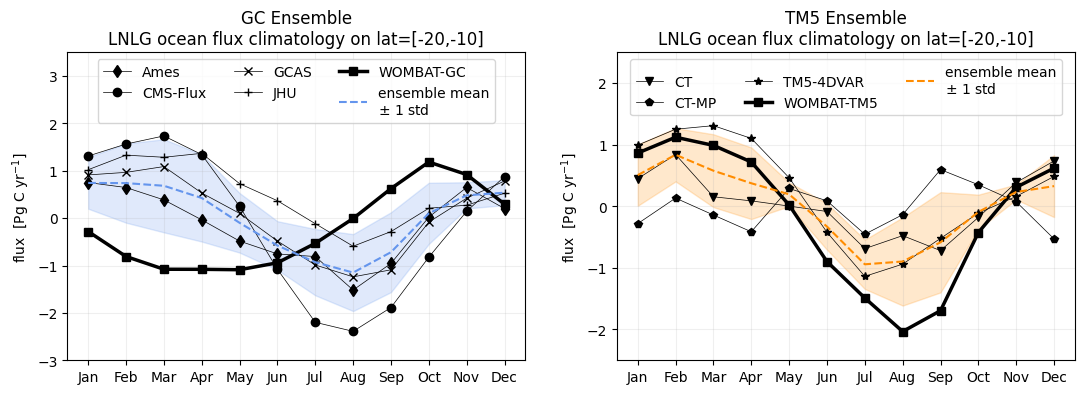

In [12]:
fig = plt.figure(figsize=(13, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

lat0, lat1 = -20, -10
obs  = 'LNLG'
flux = 'ocean_flux'

styles = {'Ames':'-d', 'CMS-Flux':'-o', 'GCAS':'-x', 'JHU':'-+', 'WOMBAT-GC':'-s',
          'CT':'-v', 'CT-MP':'-p', 'TM5-4DVAR':'-*', 'WOMBAT-TM5':'-s'}

# get ensemble members
gce  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5e = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gce_climo  = ctb.compute_climatology(gce)
tm5e_climo = ctb.compute_climatology(tm5e)

# get ensemble means and err
gcem  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5em = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcem_climo  = ctb.compute_climatology(gcem)
tm5em_climo = ctb.compute_climatology(tm5em)
gcem_climo = gcem_climo.mean('model')
tm5em_climo = tm5em_climo.mean('model')

gcerr  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5err = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcerr_climo  = ctb.compute_climatology(gcerr)
tm5err_climo = ctb.compute_climatology(tm5err)
gcerr_climo = gcerr_climo.std('model')
tm5err_climo = tm5err_climo.std('model')

months      = gce_climo.month.values
months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gce_climo.month.values]
months_fine = np.linspace(min(months), max(months), 1000)

for model in gce.coords['model'].values:
    ax1.plot(months, gce_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])
for model in tm5e.coords['model'].values:
    ax2.plot(months, tm5e_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])

ax1.plot(months, gcem_climo, '--', color=gc_color, label='ensemble mean\n$\pm$ 1 std')
ax1.fill_between(months, gcem_climo-gcerr_climo, gcem_climo+gcerr_climo, color=gc_color, alpha=0.2)
                 
ax2.plot(months, tm5em_climo, '--', color=tm5_color, label='ensemble mean\n$\pm$ 1 std')
ax2.fill_between(months, tm5em_climo-tm5err_climo, tm5em_climo+tm5err_climo, color=tm5_color, alpha=0.2)


ax1.set_ylim([-3, 3.5])
ax2.set_ylim([-2.5, 2.5])
ax1.set_title(f'GC Ensemble\n{obs} ocean flux climatology on lat=[{lat0},{lat1}]')
ax2.set_title(f'TM5 Ensemble\n{obs} ocean flux climatology on lat=[{lat0},{lat1}]')
for ax in [ax1, ax2]:
    ax.legend(ncol=3, loc='upper center')
    ax.grid(alpha=0.2)
    ax.xaxis.set_ticks(months)
    ax.xaxis.set_ticklabels(months_abbr)
    ax.set_ylabel('flux  [Pg C yr$^{-1}$]')

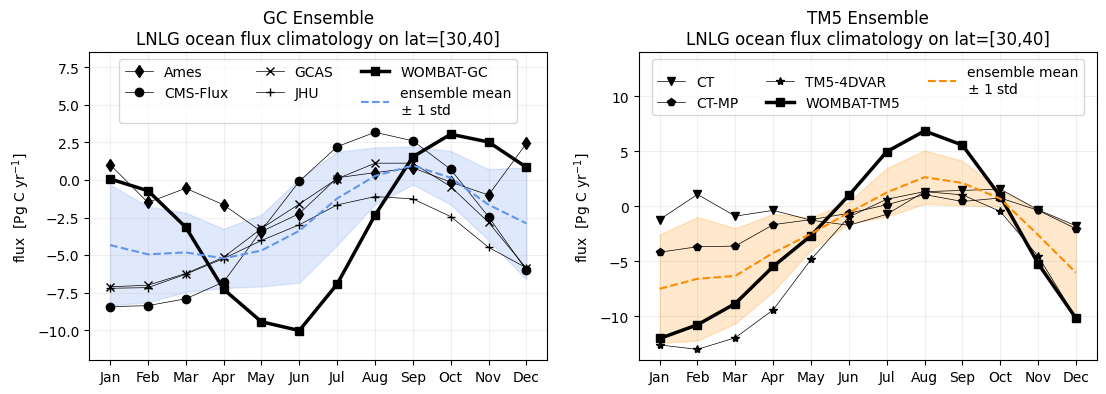

In [13]:
fig = plt.figure(figsize=(13, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

lat0, lat1 = 30, 40
obs  = 'LNLG'
flux = 'ocean_flux'

styles = {'Ames':'-d', 'CMS-Flux':'-o', 'GCAS':'-x', 'JHU':'-+', 'WOMBAT-GC':'-s',
          'CT':'-v', 'CT-MP':'-p', 'TM5-4DVAR':'-*', 'WOMBAT-TM5':'-s'}

# get ensemble members
gce  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5e = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gce_climo  = ctb.compute_climatology(gce)
tm5e_climo = ctb.compute_climatology(tm5e)

# get ensemble means and err
gcem  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5em = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcem_climo  = ctb.compute_climatology(gcem)
tm5em_climo = ctb.compute_climatology(tm5em)
gcem_climo = gcem_climo.mean('model')
tm5em_climo = tm5em_climo.mean('model')

gcerr  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5err = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcerr_climo  = ctb.compute_climatology(gcerr)
tm5err_climo = ctb.compute_climatology(tm5err)
gcerr_climo = gcerr_climo.std('model')
tm5err_climo = tm5err_climo.std('model')

months      = gce_climo.month.values
months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gce_climo.month.values]
months_fine = np.linspace(min(months), max(months), 1000)

for model in gce.coords['model'].values:
    ax1.plot(months, gce_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])
for model in tm5e.coords['model'].values:
    ax2.plot(months, tm5e_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])

ax1.plot(months, gcem_climo, '--', color=gc_color, label='ensemble mean\n$\pm$ 1 std')
ax1.fill_between(months, gcem_climo-gcerr_climo, gcem_climo+gcerr_climo, color=gc_color, alpha=0.2)
                 
ax2.plot(months, tm5em_climo, '--', color=tm5_color, label='ensemble mean\n$\pm$ 1 std')
ax2.fill_between(months, tm5em_climo-tm5err_climo, tm5em_climo+tm5err_climo, color=tm5_color, alpha=0.2)


ax1.set_ylim([-12, 8.5])
ax2.set_ylim([-14, 14])
ax1.set_title(f'GC Ensemble\n{obs} ocean flux climatology on lat=[{lat0},{lat1}]')
ax2.set_title(f'TM5 Ensemble\n{obs} ocean flux climatology on lat=[{lat0},{lat1}]')
for ax in [ax1, ax2]:
    ax.legend(ncol=3, loc='upper center')
    ax.grid(alpha=0.2)
    ax.xaxis.set_ticks(months)
    ax.xaxis.set_ticklabels(months_abbr)
    ax.set_ylabel('flux  [Pg C yr$^{-1}$]')

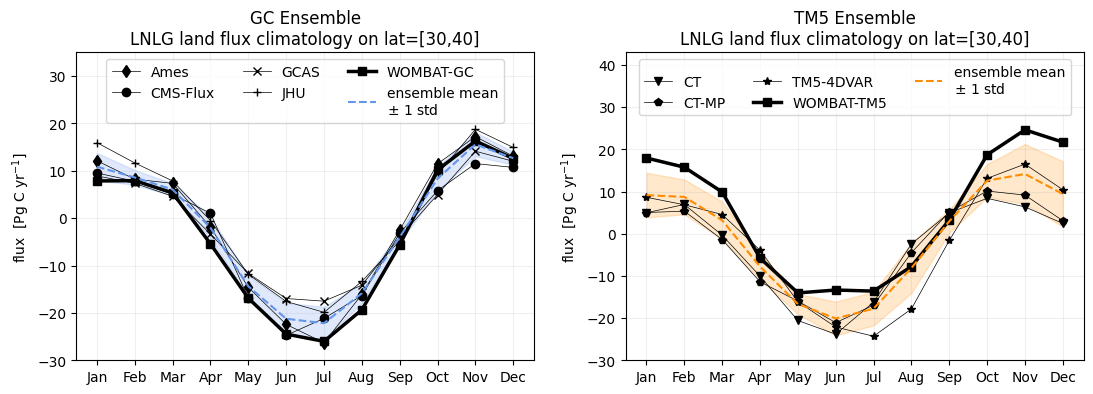

In [14]:
fig = plt.figure(figsize=(13, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

lat0, lat1 = 30, 40
obs  = 'LNLG'
flux = 'land_flux'

styles = {'Ames':'-d', 'CMS-Flux':'-o', 'GCAS':'-x', 'JHU':'-+', 'WOMBAT-GC':'-s',
          'CT':'-v', 'CT-MP':'-p', 'TM5-4DVAR':'-*', 'WOMBAT-TM5':'-s'}

# get ensemble members
gce  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5e = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gce_climo  = ctb.compute_climatology(gce)
tm5e_climo = ctb.compute_climatology(tm5e)

# get ensemble means and err
gcem  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5em = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcem_climo  = ctb.compute_climatology(gcem)
tm5em_climo = ctb.compute_climatology(tm5em)
gcem_climo = gcem_climo.mean('model')
tm5em_climo = tm5em_climo.mean('model')

gcerr  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5err = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcerr_climo  = ctb.compute_climatology(gcerr)
tm5err_climo = ctb.compute_climatology(tm5err)
gcerr_climo  = gcerr_climo.std('model')
tm5err_climo = tm5err_climo.std('model')

months      = gce_climo.month.values
months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gce_climo.month.values]
months_fine = np.linspace(min(months), max(months), 1000)

for model in gce.coords['model'].values:
    ax1.plot(months, gce_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])
for model in tm5e.coords['model'].values:
    ax2.plot(months, tm5e_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])

ax1.plot(months, gcem_climo, '--', color=gc_color, label='ensemble mean\n$\pm$ 1 std')
ax1.fill_between(months, gcem_climo-gcerr_climo, gcem_climo+gcerr_climo, color=gc_color, alpha=0.2)
                 
ax2.plot(months, tm5em_climo, '--', color=tm5_color, label='ensemble mean\n$\pm$ 1 std')
ax2.fill_between(months, tm5em_climo-tm5err_climo, tm5em_climo+tm5err_climo, color=tm5_color, alpha=0.2)


ax1.set_ylim([-30, 35])
ax2.set_ylim([-30, 43])
ax1.set_title(f'GC Ensemble\n{obs} land flux climatology on lat=[{lat0},{lat1}]')
ax2.set_title(f'TM5 Ensemble\n{obs} land flux climatology on lat=[{lat0},{lat1}]')
for ax in [ax1, ax2]:
    ax.legend(ncol=3, loc='upper center')
    ax.grid(alpha=0.2)
    ax.xaxis.set_ticks(months)
    ax.xaxis.set_ticklabels(months_abbr)
    ax.set_ylabel('flux  [Pg C yr$^{-1}$]')

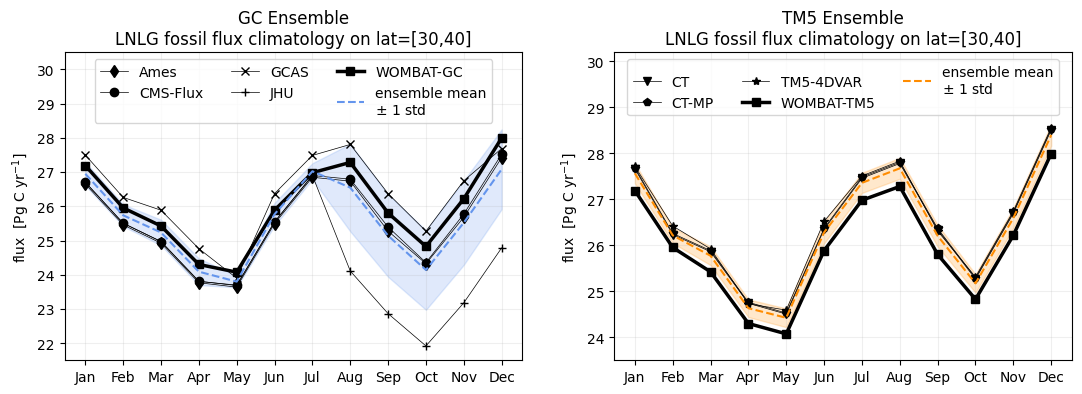

In [15]:
fig = plt.figure(figsize=(13, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

lat0, lat1 = 30, 40
obs  = 'LNLG'
flux = 'fossil_flux'

styles = {'Ames':'-d', 'CMS-Flux':'-o', 'GCAS':'-x', 'JHU':'-+', 'WOMBAT-GC':'-s',
          'CT':'-v', 'CT-MP':'-p', 'TM5-4DVAR':'-*', 'WOMBAT-TM5':'-s'}

# get ensemble members
gce  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5e = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gce_climo  = ctb.compute_climatology(gce)
tm5e_climo = ctb.compute_climatology(tm5e)

# get ensemble means and err
gcem  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5em = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcem_climo  = ctb.compute_climatology(gcem)
tm5em_climo = ctb.compute_climatology(tm5em)
gcem_climo = gcem_climo.mean('model')
tm5em_climo = tm5em_climo.mean('model')

gcerr  = horz_avg(ens_gc[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
tm5err = horz_avg(ens_tm5[obs][flux].sel(latitude=slice(lat0, lat1))) * 100
gcerr_climo  = ctb.compute_climatology(gcerr)
tm5err_climo = ctb.compute_climatology(tm5err)
gcerr_climo  = gcerr_climo.std('model')
tm5err_climo = tm5err_climo.std('model')

months      = gce_climo.month.values
months_abbr = [datetime(2026, month, 1).strftime("%b") for month in gce_climo.month.values]
months_fine = np.linspace(min(months), max(months), 1000)

for model in gce.coords['model'].values:
    ax1.plot(months, gce_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])
for model in tm5e.coords['model'].values:
    ax2.plot(months, tm5e_climo.sel(model=model), styles[model], color='k', label=model, lw=[0.5, 2.5]['WOMBAT' in model])

ax1.plot(months, gcem_climo, '--', color=gc_color, label='ensemble mean\n$\pm$ 1 std')
ax1.fill_between(months, gcem_climo-gcerr_climo, gcem_climo+gcerr_climo, color=gc_color, alpha=0.2)
                 
ax2.plot(months, tm5em_climo, '--', color=tm5_color, label='ensemble mean\n$\pm$ 1 std')
ax2.fill_between(months, tm5em_climo-tm5err_climo, tm5em_climo+tm5err_climo, color=tm5_color, alpha=0.2)


ax1.set_ylim([21.5, 30.5])
ax2.set_ylim([23.5, 30.2])
ax1.set_title(f'GC Ensemble\n{obs} fossil flux climatology on lat=[{lat0},{lat1}]')
ax2.set_title(f'TM5 Ensemble\n{obs} fossil flux climatology on lat=[{lat0},{lat1}]')
for ax in [ax1, ax2]:
    ax.legend(ncol=3, loc='upper center')
    ax.grid(alpha=0.2)
    ax.xaxis.set_ticks(months)
    ax.xaxis.set_ticklabels(months_abbr)
    ax.set_ylabel('flux  [Pg C yr$^{-1}$]')